# Bagian 3 — Training LSTM Decoder (6 Variasi)

Variasi yang dieksperimenkan:
- **Jumlah layer recurrent**: 1, 2, 3
- **Ukuran hidden state**: 128, 512

| Variasi | Num Layers | Hidden Size |
|---------|-----------|-------------|
| V1      | 1         | 128         |
| V2      | 1         | 512         |
| V3      | 2         | 128         |
| V4      | 2         | 512         |
| V5      | 3         | 128         |
| V6      | 3         | 512         |

## 0. Setup & Import

In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

# GPU setup
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print(f'GPU tersedia: {gpus[0]}')
else:
    print('Menggunakan CPU')

print(f'TensorFlow version: {tf.__version__}')

I0000 00:00:1778858417.897293    1559 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


GPU tersedia: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
TensorFlow version: 2.21.0


## 1. Load Data

In [2]:
# --------- Path konfigurasi --------- 
# PROJECT_ROOT  = os.path.abspath(os.path.join(os.getcwd(), '..'))
PROJECT_ROOT  = os.path.abspath(os.path.join(os.getcwd(), '../..'))
FEATURES_DIR  = os.path.join(PROJECT_ROOT, 'outputs', 'features')
VOCAB_DIR     = os.path.join(PROJECT_ROOT, 'outputs', 'vocab')
MODELS_DIR    = os.path.join(PROJECT_ROOT, 'models', 'lstm')
os.makedirs(MODELS_DIR, exist_ok=True)

# --------- Load metadata --------- 
with open(os.path.join(VOCAB_DIR, 'metadata.json')) as f:
    metadata = json.load(f)

VOCAB_SIZE  = metadata['vocab_size']   # 5202
MAX_SEQ_LEN = metadata['max_seq_len']  # 37
PAD_IDX     = metadata['pad_idx']      # 0
START_IDX   = metadata['start_idx']    # 1
END_IDX     = metadata['end_idx']      # 2
CNN_DIM     = 2048                     # InceptionV3 output dim

print(f'Vocab size  : {VOCAB_SIZE}')
print(f'Max seq len : {MAX_SEQ_LEN}')
print(f'CNN dim     : {CNN_DIM}')

Vocab size  : 5202
Max seq len : 37
CNN dim     : 2048


In [3]:
# --------- Load vocab ---------
with open(os.path.join(VOCAB_DIR, 'vocab.json')) as f:
    word2idx = json.load(f)
idx2word = {int(v): k for k, v in word2idx.items()}

# --------- Load tokenized captions ---------
tokenized_captions = np.load(
    os.path.join(VOCAB_DIR, 'tokenized_captions.npy'), allow_pickle=True
).item()

# --------- Load CNN features ---------
train_features  = np.load(os.path.join(FEATURES_DIR, 'inceptionv3_train_features.npy'))
val_features    = np.load(os.path.join(FEATURES_DIR, 'inceptionv3_val_features.npy'))
train_image_ids = np.load(os.path.join(FEATURES_DIR, 'inceptionv3_train_image_ids.npy'))
val_image_ids   = np.load(os.path.join(FEATURES_DIR, 'inceptionv3_val_image_ids.npy'))

print(f'Train features : {train_features.shape}')
print(f'Val features   : {val_features.shape}')
print(f'Tokenized captions (images): {len(tokenized_captions)}')

Train features : (6000, 2048)
Val features   : (1000, 2048)
Tokenized captions (images): 8091


## 2. Persiapan Dataset (Teacher Forcing)

In [4]:
def build_dataset(image_ids, features, tokenized_captions, max_len, pad_idx):
    feat_list, inp_list, tgt_list = [], [], []

    for img_id, feat in zip(image_ids, features):
        if img_id not in tokenized_captions:
            continue
        for token_ids in tokenized_captions[img_id]:
            # Potong / pad ke max_len + 1 (untuk geser)
            seq = token_ids[:max_len + 1]
            padded = seq + [pad_idx] * (max_len + 1 - len(seq))

            feat_list.append(feat)
            inp_list.append(padded[:-1])   # input : token 0..N-1
            tgt_list.append(padded[1:])    # target: token 1..N

    return (
        np.array(feat_list, dtype=np.float32),
        np.array(inp_list,  dtype=np.int32),
        np.array(tgt_list,  dtype=np.int32),
    )

print('Membangun dataset train')
train_cnn, train_inp, train_tgt = build_dataset(
    train_image_ids, train_features, tokenized_captions, MAX_SEQ_LEN, PAD_IDX
)
print('Membangun dataset val')
val_cnn, val_inp, val_tgt = build_dataset(
    val_image_ids, val_features, tokenized_captions, MAX_SEQ_LEN, PAD_IDX
)

print(f'Train samples: {len(train_cnn)}')
print(f'Val samples  : {len(val_cnn)}')
print(f'Input shape  : {train_inp.shape}')
print(f'Target shape : {train_tgt.shape}')

Membangun dataset train


Membangun dataset val
Train samples: 30000
Val samples  : 5000
Input shape  : (30000, 37)
Target shape : (30000, 37)


## 3. Definisi Model LSTM Decoder

In [5]:
def build_lstm_decoder(num_layers, hidden_size, vocab_size, cnn_dim, embed_dim=256):
    cnn_input = keras.Input(shape=(cnn_dim,), name='cnn_input')
    caption_input = keras.Input(shape=(MAX_SEQ_LEN,), dtype='int32', name='caption_input')

    # CNN feature -> embed_dim (x_{-1})
    x_neg1 = keras.layers.Dense(embed_dim, name='dense_projection')(cnn_input)
    x_neg1 = keras.layers.Reshape((1, embed_dim))(x_neg1)  # (batch, 1, embed_dim)

    # Caption tokens -> embeddings
    x_cap = keras.layers.Embedding(vocab_size, embed_dim, name='embedding')(caption_input)

    # [x_{-1}, emb(tokens)] digabung
    x = keras.layers.Concatenate(axis=1)([x_neg1, x_cap])

    # LSTM stack
    for i in range(num_layers):
        x = keras.layers.LSTM(
            hidden_size,
            return_sequences=True,
            name=f'lstm_{i}'
        )(x)

    # Output dibuang dari x_{-1} dan MAX_SEQ_LEN timestep diambil
    x = keras.layers.Lambda(lambda t: t[:, 1:, :])(x)

    # Output layer
    output = keras.layers.Dense(vocab_size, activation='softmax', name='dense_output')(x)

    model = keras.Model(
        inputs=[cnn_input, caption_input],
        outputs=output,
        name=f'lstm_L{num_layers}_H{hidden_size}'
    )
    return model

# Test build
test_model = build_lstm_decoder(num_layers=1, hidden_size=128, vocab_size=VOCAB_SIZE, cnn_dim=CNN_DIM)
test_model.summary()

I0000 00:00:1778858435.843013    1559 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2246 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "lstm_L1_H128"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ cnn_input           │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_projection    │ (None, 256)       │    524,544 │ cnn_input[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ caption_input       │ (None, 37)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 256)    │          0 │ dense_projection… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 37, 256)   │  1,331,712 │ caption_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 38, 256)   │          0 │ reshape[0][0],    │
│ (Concatenate)       │                   │            │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_0 (LSTM)       │ (None, 38, 128)   │    197,120 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 37, 128)   │          0 │ lstm_0[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_output        │ (None, 37, 5202)  │    671,058 │ lambda[0][0]      │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,724,434 (10.39 MB)

 Trainable params: 2,724,434 (10.39 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Training Loop — 6 Variasi

In [ ]:
# Konfigurasi variasi
VARIATIONS = [
    {'num_layers': 1, 'hidden_size': 128},
    {'num_layers': 1, 'hidden_size': 512},
    {'num_layers': 2, 'hidden_size': 128},
    {'num_layers': 2, 'hidden_size': 512},
    {'num_layers': 3, 'hidden_size': 128},
    {'num_layers': 3, 'hidden_size': 512},
]

# Hyperparameter training
BATCH_SIZE = 16
EPOCHS = 10
EMBED_DIM  = 256

# Simpan history semua variasi
all_histories = {}

In [7]:
for var in VARIATIONS:
    num_layers  = var['num_layers']
    hidden_size = var['hidden_size']
    var_name    = f'L{num_layers}_H{hidden_size}'
    weight_path = os.path.join(MODELS_DIR, f'lstm_{var_name}.weights.h5')

    print(f'\n{'='*60}')
    print(f'Training variasi: {var_name} ({num_layers} layer, hidden={hidden_size})')
    print(f'{'='*60}')

    # Build model
    model = build_lstm_decoder(
        num_layers=num_layers,
        hidden_size=hidden_size,
        vocab_size=VOCAB_SIZE,
        cnn_dim=CNN_DIM,
        embed_dim=EMBED_DIM,
    )

    # Compile
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy'],
    )

    # Callbacks
    callbacks = [
        keras.callbacks.ModelCheckpoint(
            weight_path,
            save_best_only=True,
            save_weights_only=True,
            monitor='val_loss',
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=2,
            verbose=1,
        ),
    ]

    # Training
    history = model.fit(
        x=[train_cnn, train_inp],
        y=train_tgt,
        validation_data=([val_cnn, val_inp], val_tgt),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1,
    )

    all_histories[var_name] = history.history
    print(f'Selesai! Bobot disimpan ke: {weight_path}')

    # Bersihkan memory GPU
    del model
    tf.keras.backend.clear_session()

print('\nSemua variasi selesai ditraining!')


Training variasi: L1_H128 (1 layer, hidden=128)


W0000 00:00:1778858454.049212    1559 cpu_allocator_impl.cc:82] Allocation of 245760000 exceeds 10% of free system memory.
W0000 00:00:1778858454.802621    1559 cpu_allocator_impl.cc:82] Allocation of 245760000 exceeds 10% of free system memory.


Epoch 1/10


I0000 00:00:1778858458.769307    2370 cuda_dnn.cc:461] Loaded cuDNN version 92200


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7338 - loss: 1.9492

W0000 00:00:1778858520.160302    1559 cpu_allocator_impl.cc:82] Allocation of 40960000 exceeds 10% of free system memory.
W0000 00:00:1778858520.272053    1559 cpu_allocator_impl.cc:82] Allocation of 40960000 exceeds 10% of free system memory.



Epoch 1: val_loss improved from None to 1.22693, saving model to /home/hanifu/CNN_RNN_LSTM/models/lstm/lstm_L1_H128.weights.h5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 72s 35ms/step - accuracy: 0.7602 - loss: 1.4722 - val_accuracy: 0.7784 - val_loss: 1.2269 - learning_rate: 0.0010
Epoch 2/10
1873/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7857 - loss: 1.1615
Epoch 2: val_loss improved from 1.22693 to 1.11431, saving model to /home/hanifu/CNN_RNN_LSTM/models/lstm/lstm_L1_H128.weights.h5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 63s 34ms/step - accuracy: 0.7887 - loss: 1.1306 - val_accuracy: 0.7894 - val_loss: 1.1143 - learning_rate: 0.0010
Epoch 3/10
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7948 - loss: 1.0493
Epoch 3: val_loss improved from 1.11431 to 1.06646, saving model to /home/hanifu/CNN_RNN_LSTM/models/lstm/lstm_L1_H128.weights.h5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 65s 35ms/step - accuracy: 0.7963 - loss: 1.0393 - val_accuracy: 0.7944 - val_loss: 1.0665 - learning_rate: 0.0010

W0000 00:00:1778859119.980785    1559 cpu_allocator_impl.cc:82] Allocation of 245760000 exceeds 10% of free system memory.


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7504 - loss: 1.6191
Epoch 1: val_loss improved from None to 1.13197, saving model to /home/hanifu/CNN_RNN_LSTM/models/lstm/lstm_L1_H512.weights.h5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 44ms/step - accuracy: 0.7722 - loss: 1.3133 - val_accuracy: 0.7878 - val_loss: 1.1320 - learning_rate: 0.0010
Epoch 2/10
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7935 - loss: 1.0547
Epoch 2: val_loss improved from 1.13197 to 1.02605, saving model to /home/hanifu/CNN_RNN_LSTM/models/lstm/lstm_L1_H512.weights.h5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 44ms/step - accuracy: 0.7965 - loss: 1.0287 - val_accuracy: 0.7971 - val_loss: 1.0260 - learning_rate: 0.0010
Epoch 3/10
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8041 - loss: 0.9316
Epoch 3: val_loss improved from 1.02605 to 0.98314, saving model to /home/hanifu/CNN_RNN_LSTM/models/lstm/lstm_L1_H512.weights.h5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 43ms/step - accuracy:

## 5. Simpan History & Plot Training/Validation Loss

In [ ]:
history_path = os.path.join(MODELS_DIR, 'training_histories.json')
with open(history_path, 'w') as f:
    json.dump(all_histories, f, indent=2)
print(f'History disimpan: {history_path}')

History disimpan: /home/hanifu/CNN_RNN_LSTM/models/lstm/training_histories.json


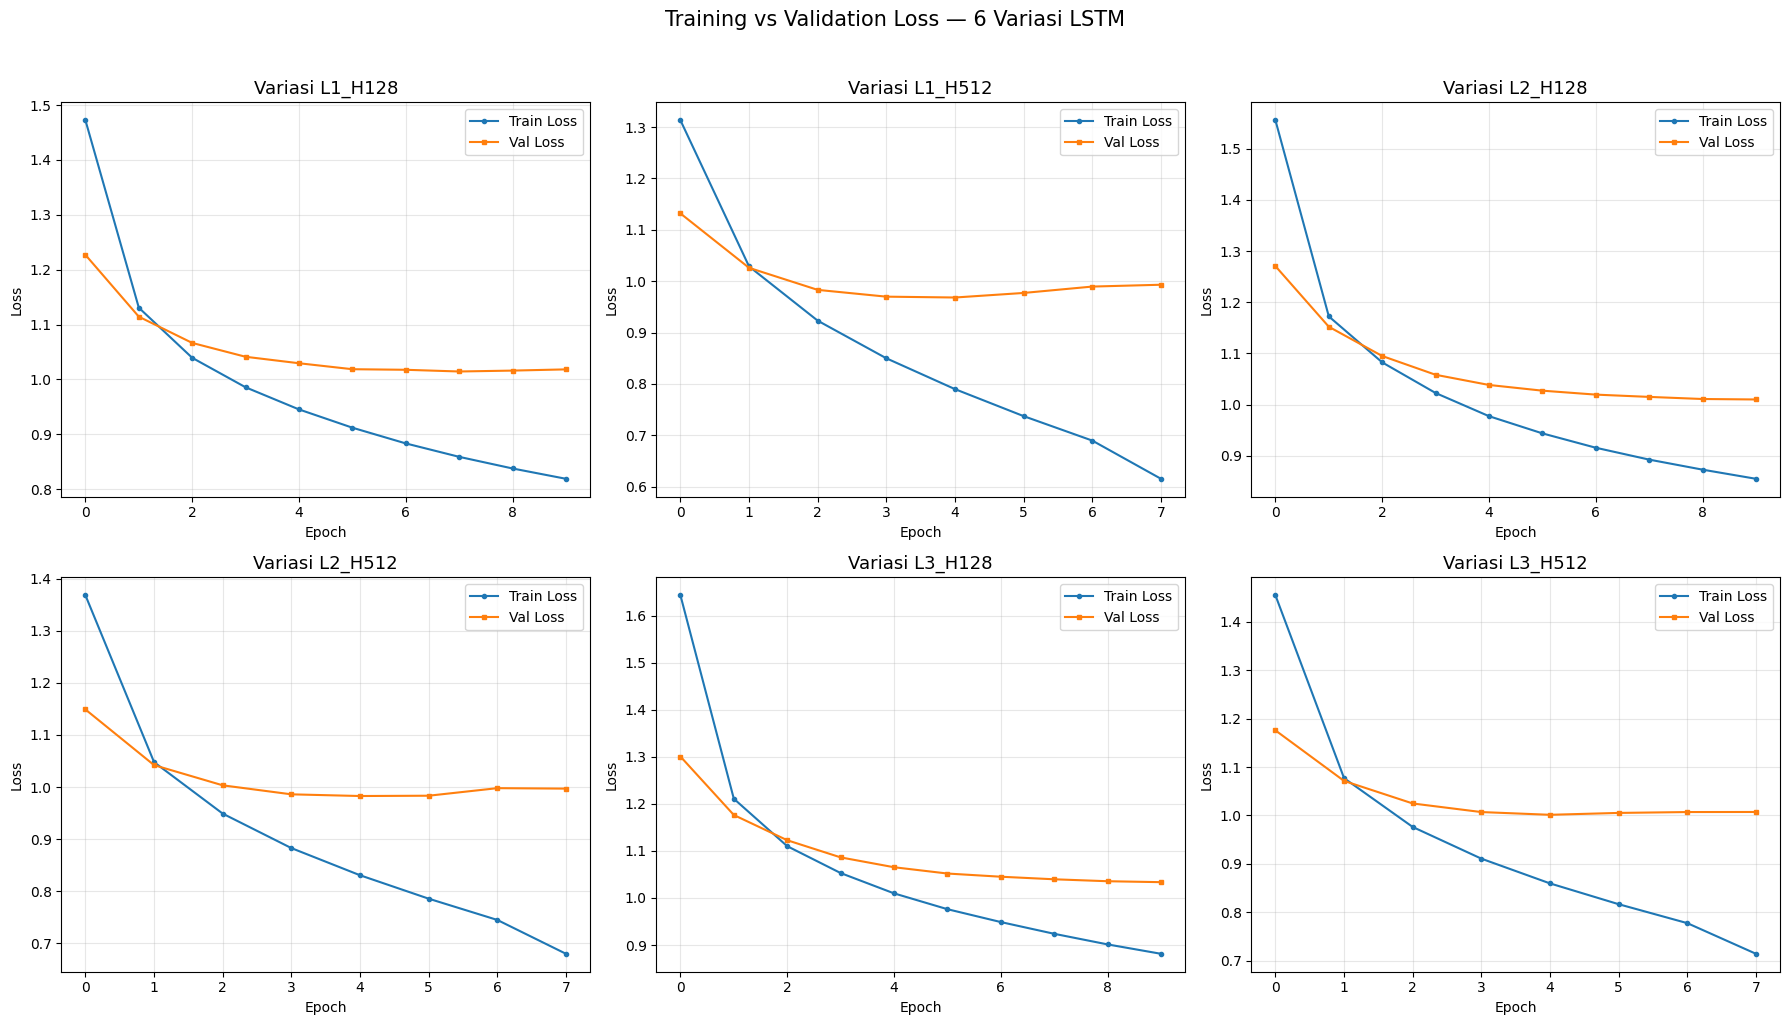

Plot disimpan!


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (var_name, history) in enumerate(all_histories.items()):
    ax = axes[idx]
    ax.plot(history['loss'],     label='Train Loss', marker='o', markersize=3)
    ax.plot(history['val_loss'], label='Val Loss',   marker='s', markersize=3)
    ax.set_title(f'Variasi {var_name}', fontsize=13)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Training vs Validation Loss — 6 Variasi LSTM', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'training_loss_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Plot disimpan!')

In [10]:
print(f'{'Variasi':<15} {'Best Val Loss':<15} {'Epochs':<10}')
print('-' * 40)
for var_name, history in all_histories.items():
    best_val  = min(history['val_loss'])
    n_epochs  = len(history['val_loss'])
    print(f'{var_name:<15} {best_val:<15.4f} {n_epochs:<10}')

Variasi         Best Val Loss   Epochs    
----------------------------------------
L1_H128         1.0144          10        
L1_H512         0.9683          8         
L2_H128         1.0102          10        
L2_H512         0.9827          8         
L3_H128         1.0336          10        
L3_H512         1.0013          8         
